# CIFAR-10 Imbalance Splits

This notebook:
- downloads CIFAR-10,
- creates 3 imbalance patterns (Long-Tailed, Step-Shaped, Almost-Single),
- shows class counts,
- saves the indices to `outputs/splits/` so other notebooks can reuse them.
The test set is **not** changed.


In [19]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Imbalance


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Imbalance


In [20]:
import os, json, random, numpy as np
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Reproducibility
SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

root = "./dataset_cache"  # Colab/local cache for CIFAR
os.makedirs("outputs/splits", exist_ok=True)
print("Seed set. Folders ready.")


Seed set. Folders ready.


Load CIFAR-10 (train & test), get labels

In [21]:
tfm_train = transforms.ToTensor()  # keep simple; no normalize needed for counting
tfm_test  = transforms.ToTensor()

train_data = datasets.CIFAR10(root=root, train=True,  download=True, transform=tmf_train if 'tmf_train' in globals() else tfm_train)
test_data  = datasets.CIFAR10(root=root, train=False, download=True, transform=tfm_test)

targets = np.array(train_data.targets)  # 50,000 labels
K = 10
class_labels = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
print("Train:", len(train_data), "Test:", len(test_data))


Train: 50000 Test: 10000


Helpers to define shapes & sample indices

In [22]:
def targets_long_tail(max_per_class=5000, decay=0.7, K=10):
    """Geometric decay: [5000, 3500, 2450, ...] clipped to >=1."""
    return [max(1, int(max_per_class*(decay**i))) for i in range(K)]

def targets_step_shape(groups=(5,5), per_class=(5000,500), K=10):
    """First 5 classes high, last 5 low by default."""
    assert sum(groups)==K and len(groups)==len(per_class)
    t = np.zeros(K, dtype=int); s = 0
    for g, pc in zip(groups, per_class):
        t[s:s+g] = pc; s += g
    return t.tolist()

def targets_almost_single(majority_class=0, majority=5000, others=500, K=10):
    """One big class, others small."""
    t = [others]*K; t[majority_class] = majority
    return t

def sample_indices_by_targets(y, per_class_targets):
    """Choose up to N from each class without replacement."""
    y = np.asarray(y); K = len(per_class_targets)
    idxs, counts = [], {}
    for c in range(K):
        want = int(per_class_targets[c])
        cls_idx = np.where(y==c)[0]
        take = min(len(cls_idx), max(0, want))
        if take > 0:
            sel = np.random.choice(cls_idx, take, replace=False)
            idxs.extend(sel.tolist())
        counts[c] = int(take)
    np.random.shuffle(idxs)
    return idxs, counts


Make the three splits

In [23]:
# Long-Tailed
lt_target = targets_long_tail(max_per_class=5000, decay=0.7, K=K)
lt_indices, lt_counts = sample_indices_by_targets(targets, lt_target)

# Step-Shaped (5 high, 5 low)
ss_target = targets_step_shape(groups=(5,5), per_class=(5000,500), K=K)
ss_indices, ss_counts = sample_indices_by_targets(targets, ss_target)

# Almost-Single (class 0 majority by default)
as_target = targets_almost_single(majority_class=0, majority=5000, others=500, K=K)
as_indices, as_counts = sample_indices_by_targets(targets, as_target)

for name, idxs, cnts in [
    ("LT", lt_indices, lt_counts),
    ("SS", ss_indices, ss_counts),
    ("AS", as_indices, as_counts),
]:
    total = len(idxs)
    ir = max(cnts.values()) / max(1, min(v for v in cnts.values() if v>0))
    print(f"{name}: total={total}  IR={ir:.1f}")


LT: total=16191  IR=24.9
SS: total=27500  IR=10.0
AS: total=9500  IR=10.0


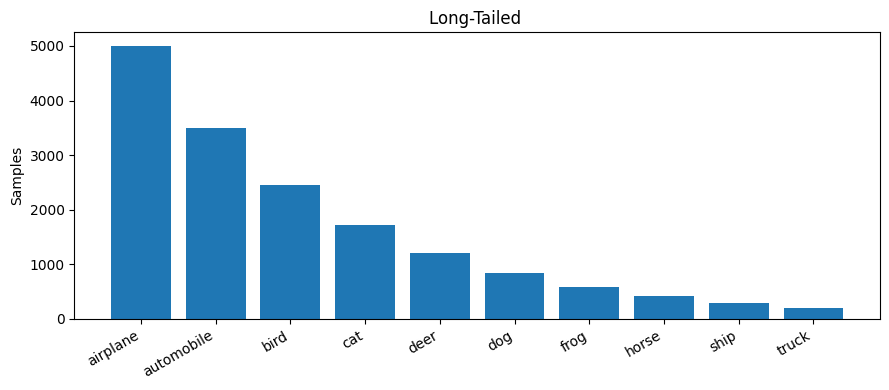

{0: 5000, 1: 3500, 2: 2449, 3: 1714, 4: 1200, 5: 840, 6: 588, 7: 411, 8: 288, 9: 201}


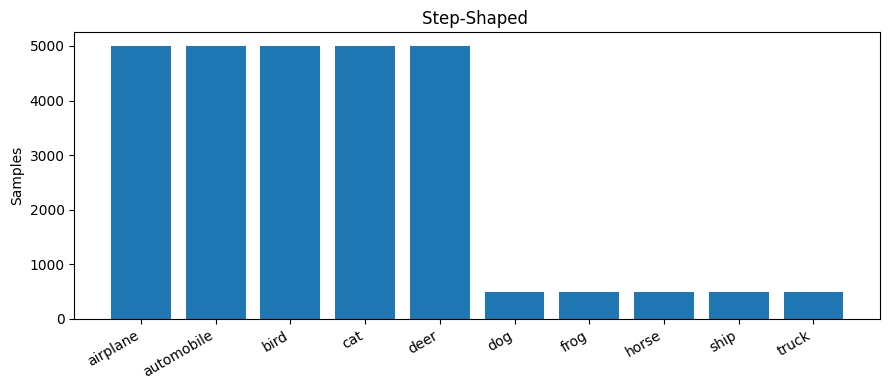

{0: 5000, 1: 5000, 2: 5000, 3: 5000, 4: 5000, 5: 500, 6: 500, 7: 500, 8: 500, 9: 500}


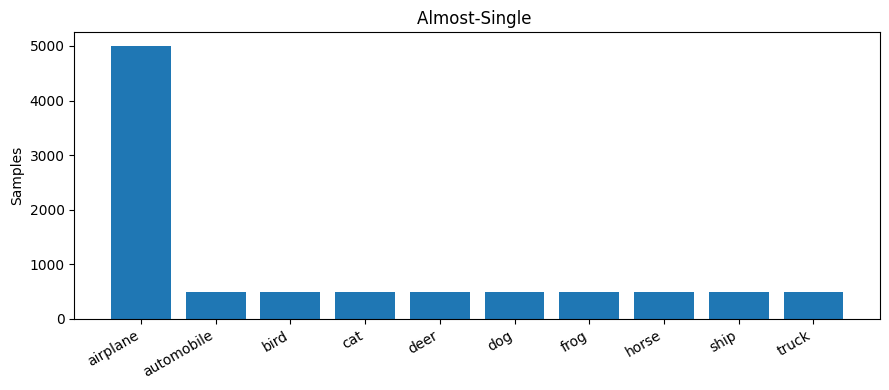

{0: 5000, 1: 500, 2: 500, 3: 500, 4: 500, 5: 500, 6: 500, 7: 500, 8: 500, 9: 500}


In [24]:
def plot_counts(indices, labels, title=""):
    idx = np.asarray(indices)
    tgt = np.asarray(targets)
    counts = np.bincount(tgt[idx], minlength=len(labels))
    nz = counts[counts>0]; ir = counts.max() / (nz.min() if len(nz)>0 else 1)
    x = np.arange(len(labels))
    plt.figure(figsize=(9,4))
    plt.bar(x, counts)
    plt.xticks(x, labels, rotation=30, ha='right')
    plt.title(f"{title} ")
    plt.ylabel("Samples"); plt.tight_layout(); plt.show()
    print(dict(enumerate(counts.tolist())))

plot_counts(lt_indices, class_labels, "Long-Tailed")
plot_counts(ss_indices, class_labels, "Step-Shaped")
plot_counts(as_indices, class_labels, "Almost-Single")


In [25]:
def save_split(path, indices, counts):
    with open(path, "w") as f:
        json.dump({
            "indices": list(map(int, indices)),
            "counts": {str(k): int(v) for k,v in counts.items()}
        }, f)

save_split("splits/lt.json", lt_indices, lt_counts)
save_split("splits/ss.json", ss_indices, ss_counts)
save_split("splits/as.json", as_indices, as_counts)

print("Saved:", os.listdir("outputs/splits"))


Saved: []
